# The following code is to answer the question:

**Q5:** How much advance warning can different variables potentially provide?

In this notebook, only certain variables will be used, since we suspect that these are the ones where we think that they would be the best at providing an answer to our question

In [1]:
# Setting up
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd().resolve()}")

Notebook directory: C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\notebooks
Project root: C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
Current working directory: C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\notebooks


In [2]:
os.chdir(PROJECT_ROOT)
print("Current working directory:")
print(Path.cwd())

Current working directory:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026


In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
# Settings
YEAR = 2020
YEARS = [YEAR]

FLOOD_PERCENTILE = 75
WARNING_PERCENTILE = 75
MAX_WARNING_DAYS = 30

In [5]:
from processing_data.loading import load_flood_masks

In [6]:
# Load flood masks
floods = load_flood_masks(years=YEARS)

print("--- FLOOD DATA ---")
print(floods.head())

print("\nColumns:")
print(floods.columns)

print("\nNumber of flood observations:")
print(len(floods))

--- FLOOD DATA ---
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0

Columns:
Index(['date', 'lat', 'lon', 'tile', 'flood_type'], dtype='str')

Number of flood observations:
4765044


In [7]:
# Load ERA5 data
era5_path = (
    PROJECT_ROOT
    / "raw_data"
    / "rainfall and runoff"
    / f"ERA5_{YEAR}.nc"
)

print("ERA5 file:")
print(era5_path)

print("\nFile exists:", era5_path.exists())

era5 = xr.open_dataset(era5_path)

print("\n--- ERA5 DATASET ---")
print(era5)

ERA5 file:
C:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026\raw_data\rainfall and runoff\ERA5_2020.nc

File exists: True

--- ERA5 DATASET ---
<xarray.Dataset> Size: 581MB
Dimensions:     (valid_time: 8784, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 290MB ...
    ro          (valid_time, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:  

In [8]:
# Daily flood activity within ERA5 coverage
era5_lat_min = float(era5.latitude.min())
era5_lat_max = float(era5.latitude.max())

era5_lon_min = float(era5.longitude.min())
era5_lon_max = float(era5.longitude.max())

floods_era5 = floods[
    (floods["lat"] >= era5_lat_min) &
    (floods["lat"] <= era5_lat_max) &
    (floods["lon"] >= era5_lon_min) &
    (floods["lon"] <= era5_lon_max)
].copy()

daily_flood_era5 = (
    floods_era5
    .groupby("date")
    .size()
    .rename("flood_pixels")
    .to_frame()
)

daily_flood_era5.index = pd.to_datetime(daily_flood_era5.index)
daily_flood_era5.index.name = "date"

full_dates = pd.date_range(
    start=f"{YEAR}-01-01",
    end=f"{YEAR}-12-31",
    freq="D"
)

daily_flood_era5 = (
    daily_flood_era5
    .reindex(full_dates, fill_value=0)
)

daily_flood_era5.index.name = "date"

print("--- DAILY FLOOD ACTIVITY ---")
print(daily_flood_era5.head())

print("\nSummary statistics:")
print(daily_flood_era5.describe())

print("\nTotal flood observations within ERA5 coverage:")
print(len(floods_era5))

--- DAILY FLOOD ACTIVITY ---
            flood_pixels
date                    
2020-01-01          9275
2020-01-02         15130
2020-01-03          9923
2020-01-04          6058
2020-01-05          9943

Summary statistics:
       flood_pixels
count    366.000000
mean   10883.672131
std    11607.443687
min        0.000000
25%     2348.750000
50%     6049.000000
75%    16781.500000
max    48445.000000

Total flood observations within ERA5 coverage:
3983424


In [9]:
# Identify high-flood days
flood_threshold = daily_flood_era5["flood_pixels"].quantile(
    FLOOD_PERCENTILE / 100
)

daily_flood_era5["high_flood"] = (
    daily_flood_era5["flood_pixels"] > flood_threshold
)

print("--- HIGH-FLOOD DAYS ---")
print(f"Percentile threshold: {FLOOD_PERCENTILE}%")
print(f"Flood threshold: {flood_threshold:.0f} flood pixels")
print("\nNumber of high-flood days:")
print(daily_flood_era5["high_flood"].sum())
print("\nFirst high-flood days:")
print(
    daily_flood_era5.loc[
        daily_flood_era5["high_flood"],
        "flood_pixels"
    ].head(15)
)

--- HIGH-FLOOD DAYS ---
Percentile threshold: 75%
Flood threshold: 16782 flood pixels

Number of high-flood days:
92

First high-flood days:
date
2020-01-07    18955
2020-01-09    21669
2020-01-10    18426
2020-01-11    30938
2020-01-12    35016
2020-01-13    24455
2020-01-14    39522
2020-01-15    21826
2020-01-16    45453
2020-01-17    30145
2020-01-18    39299
2020-01-19    32506
2020-01-20    32801
2020-01-21    40926
2020-01-22    27459
Name: flood_pixels, dtype: int64


In [10]:
# Create flood events
event_start = (
    daily_flood_era5["high_flood"]
    & ~daily_flood_era5["high_flood"].shift(1, fill_value=False)
)

daily_flood_era5["event_id"] = event_start.cumsum()

daily_flood_era5.loc[
    ~daily_flood_era5["high_flood"],
    "event_id"
] = np.nan

print("--- FLOOD EVENT LABELS ---")
print(
    daily_flood_era5[
        ["flood_pixels", "high_flood", "event_id"]
    ].head(20)
)

--- FLOOD EVENT LABELS ---
            flood_pixels  high_flood  event_id
date                                          
2020-01-01          9275       False       NaN
2020-01-02         15130       False       NaN
2020-01-03          9923       False       NaN
2020-01-04          6058       False       NaN
2020-01-05          9943       False       NaN
2020-01-06          8930       False       NaN
2020-01-07         18955        True       1.0
2020-01-08          8750       False       NaN
2020-01-09         21669        True       2.0
2020-01-10         18426        True       2.0
2020-01-11         30938        True       2.0
2020-01-12         35016        True       2.0
2020-01-13         24455        True       2.0
2020-01-14         39522        True       2.0
2020-01-15         21826        True       2.0
2020-01-16         45453        True       2.0
2020-01-17         30145        True       2.0
2020-01-18         39299        True       2.0
2020-01-19         32506        T

In [11]:
# Flood event summary

high_flood_days = daily_flood_era5[daily_flood_era5["high_flood"]].copy()

event_summary = (
    high_flood_days
    .groupby("event_id")
    .apply(
        lambda group: pd.Series({
            "start_date": group.index.min(),
            "end_date": group.index.max(),
            "duration_days": len(group),
            "peak_date": group["flood_pixels"].idxmax(),
            "peak_flood_pixels": group["flood_pixels"].max()
        })
    )
)
event_summary = event_summary.reset_index()

print("--- FLOOD EVENT SUMMARY ---")
print(event_summary)
print("\nNumber of flood events:", len(event_summary))

--- FLOOD EVENT SUMMARY ---
    event_id start_date   end_date  duration_days  peak_date  \
0        1.0 2020-01-07 2020-01-07              1 2020-01-07   
1        2.0 2020-01-09 2020-01-30             22 2020-01-16   
2        3.0 2020-02-02 2020-02-08              7 2020-02-06   
3        4.0 2020-02-10 2020-02-15              6 2020-02-10   
4        5.0 2020-02-17 2020-02-17              1 2020-02-17   
5        6.0 2020-02-19 2020-02-19              1 2020-02-19   
6        7.0 2020-02-22 2020-02-24              3 2020-02-22   
7        8.0 2020-03-02 2020-03-02              1 2020-03-02   
8        9.0 2020-03-06 2020-03-07              2 2020-03-07   
9       10.0 2020-10-05 2020-10-05              1 2020-10-05   
10      11.0 2020-10-12 2020-10-12              1 2020-10-12   
11      12.0 2020-11-04 2020-11-04              1 2020-11-04   
12      13.0 2020-11-06 2020-11-06              1 2020-11-06   
13      14.0 2020-11-11 2020-11-11              1 2020-11-11   
14      15.0

In [12]:
# Daily precipitation and runoff
tp_mm = era5["tp"] * 1000
ro_mm = era5["ro"] * 1000

tp_hourly_max = tp_mm.max(dim=["latitude", "longitude"])
ro_hourly_max = ro_mm.max(dim=["latitude", "longitude"])
daily_tp = tp_hourly_max.resample(valid_time="1D").max()
daily_ro = ro_hourly_max.resample(valid_time="1D").max()

daily_met_df = pd.DataFrame(
    {
        "precipitation_mm": daily_tp.values,
        "runoff_mm": daily_ro.values
    },
    index=pd.to_datetime(daily_tp["valid_time"].values)
)

daily_met_df.index.name = "date"

print("--- DAILY METEOROLOGICAL AND HYDROLOGICAL VARIABLES ---")
print(daily_met_df.head())
print("\nSummary statistics:")
print(daily_met_df.describe())

--- DAILY METEOROLOGICAL AND HYDROLOGICAL VARIABLES ---
            precipitation_mm  runoff_mm
date                                   
2020-01-01          3.345490   1.318932
2020-01-02          9.221554   4.561424
2020-01-03          9.266853   9.038925
2020-01-04         27.988434  27.356625
2020-01-05         16.024590  13.820648

Summary statistics:
       precipitation_mm   runoff_mm
count        366.000000  366.000000
mean          27.563082   23.997553
std           16.115543   16.884062
min            3.345490    1.318932
25%           12.321711    8.684099
50%           25.258780   20.768881
75%           39.601564   35.966873
max           71.634293   71.882248


In [13]:
# Define warning thresholds for precipitation and runoff
precipitation_threshold = daily_met_df["precipitation_mm"].quantile(WARNING_PERCENTILE / 100)

runoff_threshold = daily_met_df["runoff_mm"].quantile(WARNING_PERCENTILE / 100)

print("--- WARNING THRESHOLDS ---")
print(f"Warning percentile: {WARNING_PERCENTILE}%")
print(f"\nPrecipitation warning threshold: "f"{precipitation_threshold:.2f} mm")
print(f"Runoff warning threshold: "f"{runoff_threshold:.2f} mm")

daily_met_df["precipitation_warning"] = (daily_met_df["precipitation_mm"] > precipitation_threshold)
daily_met_df["runoff_warning"] = (daily_met_df["runoff_mm"] > runoff_threshold)

print("\nNumber of precipitation warning days:")
print(daily_met_df["precipitation_warning"].sum())
print("\nNumber of runoff warning days:")
print(daily_met_df["runoff_warning"].sum())

--- WARNING THRESHOLDS ---
Warning percentile: 75%

Precipitation warning threshold: 39.60 mm
Runoff warning threshold: 35.97 mm

Number of precipitation warning days:
92

Number of runoff warning days:
92


In [14]:
# Calculate potential warning time 
warning_results = []
for _, event in event_summary.iterrows():

    event_id = event["event_id"]
    peak_date = pd.to_datetime(event["peak_date"])
    window_start = peak_date - pd.Timedelta(days=MAX_WARNING_DAYS)
    warning_window = daily_met_df.loc[window_start : peak_date - pd.Timedelta(days=1)].copy()
    
    # PRECIPITATION WARNING
    precipitation_warning_days = warning_window[warning_window["precipitation_warning"]]
    if len(precipitation_warning_days) > 0:
        first_precipitation_warning = precipitation_warning_days.index.min()
        precipitation_warning_days_before = (peak_date - first_precipitation_warning).days
    else:

        first_precipitation_warning = pd.NaT
        precipitation_warning_days_before = np.nan

    # RUNOFF WARNING
    runoff_warning_days = warning_window[warning_window["runoff_warning"]]
    if len(runoff_warning_days) > 0:
        first_runoff_warning = runoff_warning_days.index.min()
        runoff_warning_days_before = (peak_date - first_runoff_warning).days
    else:
        first_runoff_warning = pd.NaT
        runoff_warning_days_before = np.nan

    # Store results
    warning_results.append(
        {
            "event_id": event_id,
            "peak_date": peak_date,

            "first_precipitation_warning": first_precipitation_warning,
            "precipitation_warning_days_before": (
                precipitation_warning_days_before
            ),

            "first_runoff_warning": first_runoff_warning,
            "runoff_warning_days_before": (
                runoff_warning_days_before
            )
        }
    )
warning_results_df = pd.DataFrame(warning_results)

print("--- POTENTIAL WARNING TIME BY FLOOD EVENT ---")
print(warning_results_df)

--- POTENTIAL WARNING TIME BY FLOOD EVENT ---
    event_id  peak_date first_precipitation_warning  \
0        1.0 2020-01-07                         NaT   
1        2.0 2020-01-16                  2020-01-12   
2        3.0 2020-02-06                  2020-01-12   
3        4.0 2020-02-10                  2020-01-12   
4        5.0 2020-02-17                  2020-01-23   
5        6.0 2020-02-19                  2020-01-23   
6        7.0 2020-02-22                  2020-01-23   
7        8.0 2020-03-02                  2020-02-02   
8        9.0 2020-03-07                  2020-02-15   
9       10.0 2020-10-05                  2020-09-05   
10      11.0 2020-10-12                  2020-09-12   
11      12.0 2020-11-04                  2020-10-05   
12      13.0 2020-11-06                  2020-10-08   
13      14.0 2020-11-11                  2020-10-14   
14      15.0 2020-11-13                  2020-10-14   
15      16.0 2020-11-15                  2020-10-16   
16      17.0 2020-1

In [15]:
# Most recent warning before each flood peak
recent_warning_results = []
for _, event in event_summary.iterrows():
    event_id = event["event_id"]
    peak_date = pd.to_datetime(event["peak_date"])
    window_start = peak_date - pd.Timedelta(days=MAX_WARNING_DAYS)
    warning_window = daily_met_df.loc[window_start : peak_date - pd.Timedelta(days=1)].copy()

    # MOST RECENT PRECIPITATION WARNING
    precipitation_warning_days = warning_window[warning_window["precipitation_warning"]]
    if len(precipitation_warning_days) > 0:
        last_precipitation_warning = (precipitation_warning_days.index.max())
        precipitation_lead_days = (peak_date - last_precipitation_warning).days
    else:
        last_precipitation_warning = pd.NaT
        precipitation_lead_days = np.nan

    # MOST RECENT RUNOFF WARNING
    runoff_warning_days = warning_window[warning_window["runoff_warning"]]
    if len(runoff_warning_days) > 0:
        last_runoff_warning = runoff_warning_days.index.max()
        runoff_lead_days = (peak_date - last_runoff_warning).days
    else:
        last_runoff_warning = pd.NaT
        runoff_lead_days = np.nan

    # Store results
    recent_warning_results.append(
        {
            "event_id": event_id,
            "peak_date": peak_date,

            "last_precipitation_warning":
                last_precipitation_warning,

            "precipitation_lead_days":
                precipitation_lead_days,

            "last_runoff_warning":
                last_runoff_warning,

            "runoff_lead_days":
                runoff_lead_days
        }
    )
recent_warning_df = pd.DataFrame(recent_warning_results)

print("--- MOST RECENT WARNING BEFORE FLOOD PEAK ---")
print(recent_warning_df)

--- MOST RECENT WARNING BEFORE FLOOD PEAK ---
    event_id  peak_date last_precipitation_warning  precipitation_lead_days  \
0        1.0 2020-01-07                        NaT                      NaN   
1        2.0 2020-01-16                 2020-01-13                      3.0   
2        3.0 2020-02-06                 2020-02-04                      2.0   
3        4.0 2020-02-10                 2020-02-04                      6.0   
4        5.0 2020-02-17                 2020-02-15                      2.0   
5        6.0 2020-02-19                 2020-02-15                      4.0   
6        7.0 2020-02-22                 2020-02-15                      7.0   
7        8.0 2020-03-02                 2020-02-25                      6.0   
8        9.0 2020-03-07                 2020-03-02                      5.0   
9       10.0 2020-10-05                 2020-10-04                      1.0   
10      11.0 2020-10-12                 2020-10-11                      1.0   
11    

In [16]:
# Summary of potential warning time
warning_summary = recent_warning_df[["precipitation_lead_days", "runoff_lead_days"]].describe()
print("--- POTENTIAL ADVANCE WARNING SUMMARY ---")
print(warning_summary)

print("\nEvents with a precipitation warning:")
print(recent_warning_df["precipitation_lead_days"].notna().sum(), "out of", len(recent_warning_df))

print("\nEvents with a runoff warning:")
print(recent_warning_df["runoff_lead_days"].notna().sum(), "out of", len(recent_warning_df))

--- POTENTIAL ADVANCE WARNING SUMMARY ---
       precipitation_lead_days  runoff_lead_days
count                 20.00000         20.000000
mean                   5.45000          9.650000
std                    3.70597          7.080552
min                    1.00000          1.000000
25%                    2.75000          3.750000
50%                    4.50000          9.500000
75%                    7.25000         14.250000
max                   14.00000         23.000000

Events with a precipitation warning:
20 out of 21

Events with a runoff warning:
20 out of 21


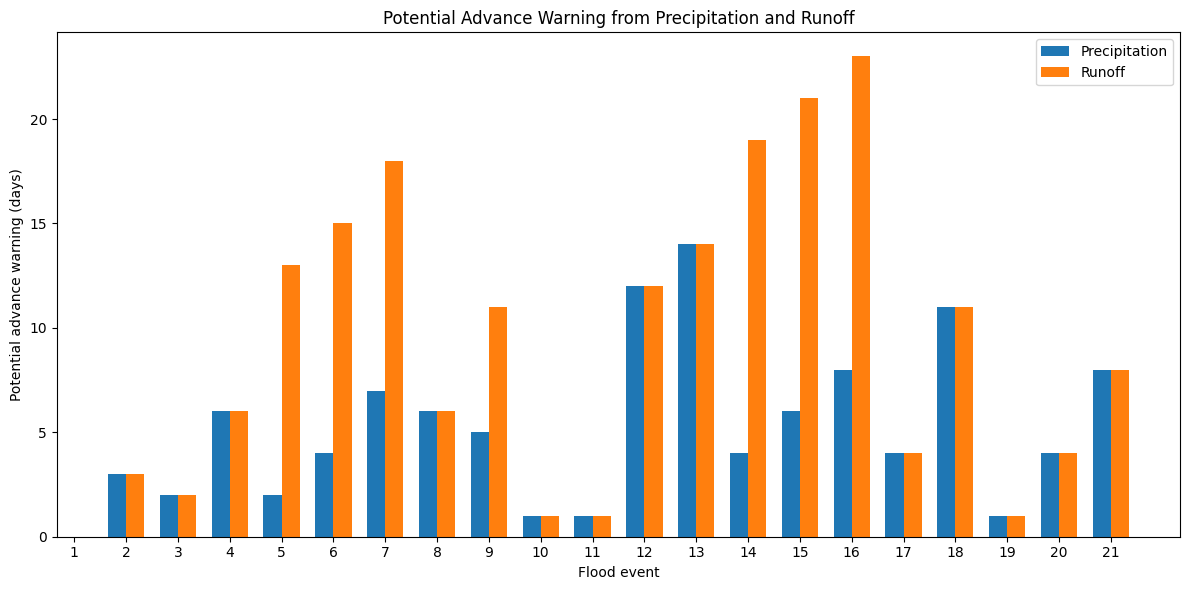

In [17]:
# Compare potential warning times
plt.figure(figsize=(12, 6))
x = np.arange(len(recent_warning_df))
width = 0.35
plt.bar(x - width / 2, recent_warning_df["precipitation_lead_days"], width, label="Precipitation")
plt.bar(x + width / 2, recent_warning_df["runoff_lead_days"], width, label="Runoff")
plt.xticks(x, recent_warning_df["event_id"].astype(int))
plt.xlabel("Flood event")
plt.ylabel("Potential advance warning (days)")
plt.title("Potential Advance Warning from Precipitation and Runoff")
plt.legend()
plt.tight_layout()
plt.show()

## Potential advance warning from precipitation and runoff

To estimate the potential advance warning provided by precipitation and runoff, warning thresholds were defined as the 75th percentile of each variable. A potential warning was identified when precipitation or runoff exceeded its respective threshold before the peak of an observed flood event. The most recent warning before each flood peak was used to calculate the potential lead time.

Both precipitation and runoff provided a warning before 20 out of the 21 identified flood events. However, runoff generally provided substantially longer advance warning than precipitation. The mean lead time for precipitation was 5.45 days, compared with 9.65 days for runoff. The median lead times were 4.5 days for precipitation and 9.5 days for runoff, respectively.

The maximum potential warning time was 14 days for precipitation and 23 days for runoff. The results therefore suggest that runoff may provide earlier warning of approaching flood peaks than precipitation when using these threshold-based indicators.

Overall, precipitation appears to provide useful short- to medium-term advance warning, typically several days before a flood peak. Runoff shows greater potential for longer-term warning, with an average lead time of almost ten days. However, these warning times should be interpreted as potential warning based on historical threshold exceedances rather than as a predictive forecasting system. Further analysis would be required to determine how reliable these indicators are and how often warnings would occur without a subsequent flood event.